## Itent-to-treat and Treatment effect in high dimensional setting

#### This part try to estimate the itent-to-treat as well as the treatment effect using high dimensioanl machine learning methods

 we start by creating relevant variables which will serve as covariates for our model

In [1]:
# imports
import pandas as pd
import numpy as np

# load data
df = pd.read_csv("data/df_eda_clean.csv")
data = df.copy()

# region variables
data["IdF"] = (data["nregion"] == "116").astype(int)
data["North"] = (data["nregion"] == "311").astype(int)
data["Otherregion"] = 1 - data["IdF"] - data["North"]

# reason for job loss
data["EconLayoff"] = (data["motins"] == "1").astype(int)
data["PersLayoff"] = (data["motins"] == "2").astype(int)
data["EndCDD"] = (data["motins"] == "4").astype(int)
data["EndInterim"] = (data["motins"] == "5").astype(int)

data["Otherend"] = 1 - data[
    ["EconLayoff","PersLayoff","EndCDD","EndInterim"]
].sum(axis=1)

# experience
data["exper0"] = (data["exper"] == "00").astype(int)

data["exper1_5"] = data["exper"].isin(
    ["01","02","03","04","05"]
).astype(int)

data["experM5"] = 1 - data["exper0"] - data["exper1_5"]

# statistical risk group
data["rsqstat2"] = (data["rsqstat"] == "RS2").astype(int)
data["rsqstat3"] = (data["rsqstat"] == "RS3").astype(int)

data["Orsqstat"] = 1 - data["rsqstat2"] - data["rsqstat3"]

# job search type
data["tempcomp"] = (data["temps"] == "1").astype(int)
data["Otemp"] = 1 - data["tempcomp"]

# sensitive area
data["dezus"] = (data["zus"] == "ZU").astype(int)

# wage expectations
for s in ["A","B","C","D","E"]:
    data[f"salaire{s}"] = (data["salaire"] == s).astype(int)

data["salaireG"] = data["salaire"].isin(["G",""]).astype(int)

# job type
data["ce1"] = (data["cemploi"] == "CE1").astype(int)
data["ce2"] = (data["cemploi"] == "CE2").astype(int)
data["cemiss"] = (data["cemploi"] == "").astype(int)

# first time unemployed
data["primo"] = (data["ndem"] == 1).astype(int)

# socioprofessional category
data["Cadre"] = (data["CS"] == 3).astype(int)
data["Techn"] = (data["CS"] == 4).astype(int)

data["EmployQ"] = (data["CS"] == 51).astype(int)
data["EmployNQ"] = (data["CS"] == 56).astype(int)

data["OuvrQ"] = (data["CS"] == 61).astype(int)
data["OuvrNQ"] = data["CS"].isin([66,99]).astype(int)

# nationality groups
data["nation_int"] = pd.to_numeric(data["nation"], errors="coerce")

data["African"] = (
    (data["nation_int"] >= 31) & (data["nation_int"] <= 49)
).astype(int)

data["EasternEurope"] = (
    ((data["nation_int"] >= 90) & (data["nation_int"] <= 98)) |
    (data["nation_int"].isin([24, 25, 27]))
).astype(int)

data["SouthEuropTurkey"] = data["nation_int"].isin(
    [2, 3, 14, 19, 21, 22, 24, 27, 26]
).astype(int)

# children
data["nochild"] = (data["nenf"] == 0).astype(int)
data["onechild"] = (data["nenf"] == 1).astype(int)
data["twoormorechild"] = (data["nenf"] > 1).astype(int)



# randomization cohort
data["Q1"] = data["mois_saisie_occ"].between(1,3).astype(int)
data["Q2"] = data["mois_saisie_occ"].between(4,6).astype(int)
data["Q3"] = data["mois_saisie_occ"].between(7,9).astype(int)
data["Q4"] = data["mois_saisie_occ"].between(10,12).astype(int)


print("Dataset prepared successfully")

Dataset prepared successfully


In [2]:
data.columns

Index(['CVE', 'OPP', 'SAMPLE_CVEOPP', 'Z', 'acceptationCVE', 'acceptationOPP',
       'EMPLOI_3MOIS', 'EMPLOI_6MOIS', 'EMPLOI_9MOIS', 'EMPLOI_12MOIS', 'age',
       'femme', 'marie', 'nenf', 'etranger', 'zus', 'duree_listes_horsAR',
       'nivetude1', 'nivetude2', 'nivetude3', 'nivetude4', 'salaire', 'exper',
       'nregion', 'CS', 'rsqstat', 'motins', 'cemploi', 'temps', 'ndem',
       'nation', 'mois_saisie_occ', 'POIDS_PZ_3MOIS', 'POIDS_PZ_6MOIS',
       'POIDS_PZ_9MOIS', 'POIDS_PZ_12MOIS', 'agegr2635', 'agegr3645',
       'agegr4655', 'agegr56', 'IdF', 'North', 'Otherregion', 'EconLayoff',
       'PersLayoff', 'EndCDD', 'EndInterim', 'Otherend', 'exper0', 'exper1_5',
       'experM5', 'rsqstat2', 'rsqstat3', 'Orsqstat', 'tempcomp', 'Otemp',
       'dezus', 'salaireA', 'salaireB', 'salaireC', 'salaireD', 'salaireE',
       'salaireG', 'ce1', 'ce2', 'cemiss', 'primo', 'Cadre', 'Techn',
       'EmployQ', 'EmployNQ', 'OuvrQ', 'OuvrNQ', 'nation_int', 'African',
       'EasternEurope',

In [3]:
# list of covariates

covariates = [

    # region
    "IdF",
    "North",
    "Otherregion",

    # reason for job loss
    "EconLayoff",
    "PersLayoff",
    "EndCDD",
    "EndInterim",
    "Otherend",

    # experience
    "exper0",
    "exper1_5",
    "experM5",

    # statistical risk score
    "rsqstat2",
    "rsqstat3",
    "Orsqstat",

    # job search type
    "tempcomp",
    "Otemp",

    # sensitive area
    "dezus",

    # wage expectations
    "salaireA",
    "salaireB",
    "salaireC",
    "salaireD",
    "salaireE",
    "salaireG",

    # job type searched
    "ce1",
    "ce2",
    "cemiss",

    # first time unemployed
    "primo",

    # socioprofessional category
    "Cadre",
    "Techn",
    "EmployQ",
    "EmployNQ",
    "OuvrQ",
    "OuvrNQ",

    # nationality groups
    "African",
    "EasternEurope",
    "SouthEuropTurkey",

    # family
    "nochild",
    "onechild",
    "twoormorechild",

    # gender
    "femme",

    # cohort of randomization
    "Q1",
    "Q2",
    "Q3",
    "Q4",
    
    # age class
    "agegr2635",
    "agegr3645",
    "agegr4655",
    "agegr56"
]

#### Part 1 : itent-to-treat

In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
import statsmodels.api as sm

results = []

df = data[data["SAMPLE_CVEOPP"] == 1].copy()

for d in [3,6,9,12]:

    #print(d)
    Y = df[f"EMPLOI_{d}MOIS"]
    X = df[covariates]
    w = df[f"POIDS_PZ_{d}MOIS"]

    # traitements ITT
    D = df[["CVE","OPP"]]

    # Lasso Y ~ X
    lasso = LassoCV(cv=5)
    lasso.fit(X, Y)
    Y_res = Y - lasso.predict(X)
    #selected_Y = X.columns[lasso.coef_ != 0]

    #print("Variables sélectionnées pour Y:")
    #print(list(selected_Y))
    
    # résidualisation des traitements
    D_res = pd.DataFrame()

    for col in D.columns:
        lasso.fit(X, D[col])
        D_res[col] = D[col] - lasso.predict(X)
        #selected_D = pd.DataFrame()
        #selected_D[col] = list(X.columns[lasso.coef_ != 0])

        #print(f"\nVariables sélectionnées pour {col}:")
        #print(selected_D[col])
    # regression finale
    X_final = sm.add_constant(D_res)

    model = sm.WLS(Y_res, X_final, weights=w)
    res = model.fit(cov_type="HC1")

    results.append({
        "months": d,
        "CVE": 100*res.params["CVE"],
        "OPP": 100*res.params["OPP"],
        "se_CVE": 100*res.bse["CVE"],
        "se_OPP": 100*res.bse["OPP"]
    })

results_DL = pd.DataFrame(results)

print(results_DL)

   months       CVE       OPP    se_CVE    se_OPP
0       3  3.150748  0.875763  0.932872  0.668729
1       6  2.967735  1.553785  1.164842  0.852363
2       9  3.793709  2.223601  1.264138  0.934231
3      12  2.569762  2.103010  1.313715  0.977616


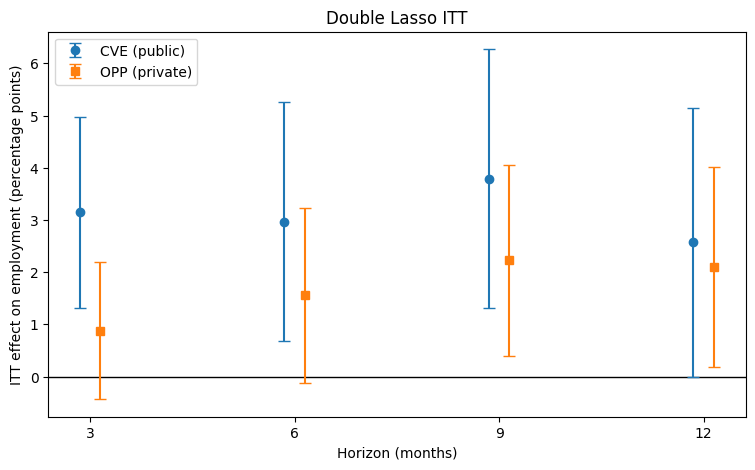

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def plot_event_study_style(results):

    df = results.sort_values("months")

    x = df["months"].values
    offset = 0.15   # taille du décalage

    x_cve = x - offset
    x_opp = x + offset

    z = 1.96

    plt.figure(figsize=(9,5))
    plt.axhline(0, color="black", linewidth=1)

    # CVE
    plt.errorbar(
        x_cve,
        df["CVE"],
        yerr=z*df["se_CVE"],
        fmt="o",
        capsize=4,
        label="CVE (public)"
    )

    # OPP
    plt.errorbar(
        x_opp,
        df["OPP"],
        yerr=z*df["se_OPP"],
        fmt="s",
        capsize=4,
        label="OPP (private)"
    )

    plt.xticks(x)
    plt.xlabel("Horizon (months)")
    plt.ylabel("ITT effect on employment (percentage points)")
    plt.title("Double Lasso ITT")
    plt.legend()

    plt.show()
    
plot_event_study_style(results_DL)

In [6]:
#pip install doubleml

In [ ]:
# Double ML
import doubleml as dml
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

# restriction de l'échantillon
df = data[data["SAMPLE_CVEOPP"] == 1].copy()
results = []
for d in [3,6,9,12]:
    
    y_var = f"EMPLOI_{d}MOIS"

    # objet DoubleMLData
    dml_data = dml.DoubleMLData(
        df,
        y_col=y_var,
        d_cols=["CVE","OPP"],
        x_cols=covariates
    )

    # random forest regressor
    ml_l = RandomForestRegressor(
    n_estimators=50,
    max_depth=5
    )

    #random forest classifier
    ml_m = RandomForestClassifier(
    n_estimators=50,
    max_depth=5
    )

    # modèle DML
    dml_model = dml.DoubleMLPLR(
    dml_data,
    ml_l=ml_l,
    ml_m=ml_m,
    n_folds=5
    #sample_weight=df[f"POIDS_PZ_{d}MOIS"].values
)

    # estimation
    dml_model.fit()

    # récupération résultats
    coef = dml_model.coef
    se = dml_model.se

    results.append({
        "months": d,
        "CVE": 100*coef[0],
        "OPP": 100*coef[1],
        "se_CVE": 100*se[0],
        "se_OPP": 100*se[1]
    })

# tableau final
results_DML = pd.DataFrame(results)

print(results_DML)

TypeError: DoubleMLPLR.__init__() got an unexpected keyword argument 'sample_weight'

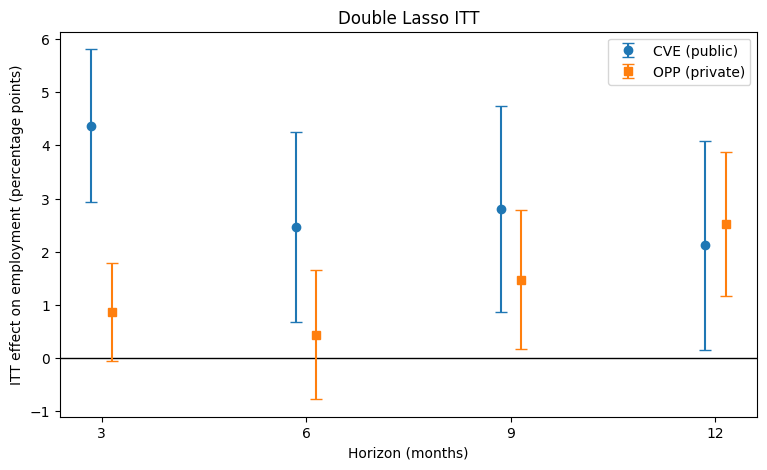

In [ ]:
plot_event_study_style(results_DML)

In [ ]:
dml.double_ml.DoubleML.